In [ ]:
try:
    import Bio
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "biopython"], check=True)

import math, io, textwrap, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio.Restriction import RestrictionBatch, Analysis, CommOnly
try:
    from Bio.SeqUtils import MeltingTemp as _mt
except Exception:
    _mt = None

EMAIL      = "you@example.com"
ACCESSION  = "L09137"
USE_NCBI   = False
Entrez.email = EMAIL

TYPE_COLORS = {
    "CDS": "#d1495b", "gene": "#c1666b", "rep_origin": "#2e86ab",
    "promoter": "#e3a008", "terminator": "#8d99ae", "misc_feature": "#6a994e",
    "primer_bind": "#9d4edd", "protein_bind": "#457b9d", "source": "#adb5bd",
}
def _color(ftype): return TYPE_COLORS.get(ftype, "#6a994e")

MCS = "GAATTCGAGCTCGGTACCCGGGGATCCTCTAGAGTCGACCTGCAGGCATGCAAGCTT"

def _synthetic_plasmid():
    random.seed(19)
    body = "".join(random.choice("ACGT") for _ in range(2686))
    seq  = body[:400] + MCS + body[400:]
    rec  = SeqRecord(Seq(seq), id="pDEMO", name="pDEMO",
                     description="Synthetic offline demo plasmid (SpliceCraft-Colab)")
    rec.annotations["topology"] = "circular"
    rec.annotations["molecule_type"] = "ds-DNA"
    def feat(s, e, strand, ftype, label):
        f = SeqFeature(FeatureLocation(s, e, strand=strand), type=ftype)
        f.qualifiers["label"] = [label]; return f
    rec.features += [
        feat(400, 400 + len(MCS), 1, "misc_feature", "MCS"),
        feat(700, 1561, 1, "CDS", "AmpR"),
        feat(1700, 2260, -1, "rep_origin", "ori"),
        feat(2350, 2686, 1, "CDS", "lacZ-alpha"),
    ]
    rec.features[1].qualifiers["product"] = ["beta-lactamase (demo)"]
    return rec

def load_record():
    if USE_NCBI and "@" in EMAIL and not EMAIL.startswith("you@"):
        try:
            h = Entrez.efetch(db="nucleotide", id=ACCESSION,
                              rettype="gbwithparts", retmode="text")
            rec = SeqIO.read(h, "genbank"); h.close()
            print(f"✓ Fetched {ACCESSION} from NCBI: {rec.description}")
            return rec
        except Exception as e:
            print(f"⚠ NCBI fetch failed ({e}); using synthetic demo plasmid.")
    else:
        print("ℹ USE_NCBI is off (or EMAIL not set) — using synthetic demo plasmid.")
    return _synthetic_plasmid()

def upload_gb():
    from google.colab import files
    up = files.upload()
    name = next(iter(up))
    return SeqIO.read(io.StringIO(up[name].decode()), "genbank")

def label_of(f):
    for k in ("label", "gene", "product", "note"):
        if k in f.qualifiers: return f.qualifiers[k][0]
    return f.type

def norm_features(rec, skip_source=True, min_len=0):
    L = len(rec.seq); out = []
    for f in rec.features:
        if skip_source and f.type in ("source",): continue
        s = int(f.location.start); e = int(f.location.end)
        if (e - s) < min_len: continue
        out.append(dict(start=s % L, end=e % L, strand=f.location.strand or 1,
                        type=f.type, label=label_of(f), color=_color(f.type)))
    return out

In [ ]:
def _ang(bp, L):  return math.pi/2 - 2*math.pi*(bp/L)
def _pt(bp, r, L):
    a = _ang(bp, L); return r*math.cos(a), r*math.sin(a)
def _arc(s, e, r, L, n=240):
    if e < s: e += L
    bps = np.linspace(s, e, max(2, int(n*(e-s)/L)+2))
    return ([r*math.cos(_ang(b, L)) for b in bps],
            [r*math.sin(_ang(b, L)) for b in bps])

def gc_percent(seq):
    s = str(seq).upper(); n = len(s) or 1
    return 100.0 * (s.count("G") + s.count("C")) / n

def circular_map(rec, title=None, show_gc=True):
    L = len(rec.seq); feats = norm_features(rec)
    fig, ax = plt.subplots(figsize=(8, 8)); R = 1.0

    if show_gc:
        w = max(30, L // 120); step = max(1, w // 2); mean = gc_percent(rec.seq)
        s = str(rec.seq).upper()
        for i in range(0, L, step):
            win = s[i:i+w] or s[i:] + s[:(i+w) % L]
            dev = (gc_percent(win) - mean) / 100.0
            rr = 0.72 + dev * 0.9
            x0, y0 = _pt(i, 0.72, L); x1, y1 = _pt(i, rr, L)
            ax.plot([x0, x1], [y0, y1],
                    color="#2e86ab" if dev >= 0 else "#d1495b", lw=1, alpha=0.5, zorder=1)

    xs, ys = _arc(0, L, R, L); ax.plot(xs, ys, color="#333", lw=2.5, zorder=2)
    step = max(1, round(L/12/100)*100) or max(1, L//12)
    for t in range(0, L, step):
        x0, y0 = _pt(t, R*1.015, L); x1, y1 = _pt(t, R*1.045, L)
        ax.plot([x0, x1], [y0, y1], color="#999", lw=1, zorder=2)
        lx, ly = _pt(t, R*1.10, L)
        ax.text(lx, ly, f"{t:,}", ha="center", va="center", fontsize=7, color="#777")

    for f in feats:
        outer = f["strand"] >= 0
        rr = R + 0.09 if outer else R - 0.09
        xs, ys = _arc(f["start"], f["end"], rr, L)
        ax.plot(xs, ys, color=f["color"], lw=10, solid_capstyle="butt", alpha=0.9, zorder=3)
        tip = f["end"] if outer else f["start"]
        a = _ang(tip, L); tx, ty = rr*math.cos(a), rr*math.sin(a)
        d = -1 if outer else 1
        tanx, tany = -math.sin(a)*d, math.cos(a)*d
        px, py = math.cos(a), math.sin(a)
        ln, wd = 0.055, 0.052
        ax.add_patch(Polygon([(tx+tanx*ln, ty+tany*ln),
                              (tx+px*wd,   ty+py*wd),
                              (tx-px*wd,   ty-py*wd)],
                             color=f["color"], zorder=4))
        span = (f["end"] - f["start"]) % L
        mid = (f["start"] + span/2) % L
        lx, ly = _pt(mid, (rr + 0.16) if outer else (rr - 0.16), L)
        ax.text(lx, ly, f["label"], ha="center", va="center",
                fontsize=8.5, color=f["color"], weight="bold", zorder=5)

    circ = "circular" if rec.annotations.get("topology") == "circular" else "linear"
    ax.text(0,  0.05, title or rec.name, ha="center", va="center", fontsize=15, weight="bold")
    ax.text(0, -0.07, f"{L:,} bp · {gc_percent(rec.seq):.1f}% GC · {circ}",
            ha="center", va="center", fontsize=9.5, color="#555")
    ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
    ax.set_aspect("equal"); ax.axis("off"); plt.tight_layout(); plt.show()

In [ ]:
def linear_map(rec):
    L = len(rec.seq); feats = norm_features(rec)
    fig, ax = plt.subplots(figsize=(11, 2.6))
    ax.hlines(0, 0, L, color="#333", lw=2)
    for f in feats:
        y = 0.35 if f["strand"] >= 0 else -0.35
        s, e = f["start"], f["end"]
        segs = [(s, e)] if e >= s else [(s, L), (0, e)]
        for a, b in segs:
            ax.annotate("", xy=(b if f["strand"] >= 0 else a, y),
                        xytext=(a if f["strand"] >= 0 else b, y),
                        arrowprops=dict(arrowstyle="-|>", color=f["color"], lw=7, alpha=0.85))
        ax.text((s + ((e - s) % L)/2) % L, y + (0.28 if y > 0 else -0.28), f["label"],
                ha="center", va="center", fontsize=8.5, color=f["color"], weight="bold")
    ax.set_xlim(-L*0.02, L*1.02); ax.set_ylim(-1, 1)
    ax.set_yticks([]); ax.set_xlabel("position (bp)")
    ax.set_title(f"{rec.name} — linear view", fontsize=11)
    for sp in ("top", "left", "right"): ax.spines[sp].set_visible(False)
    plt.tight_layout(); plt.show()

def gc_skew_plot(rec, window=None):
    s = str(rec.seq).upper(); L = len(s)
    window = window or max(50, L // 100); skew = []; run = 0
    for i in range(0, L, window):
        w = s[i:i+window]; g, c = w.count("G"), w.count("C")
        run += (g - c) / max(1, g + c); skew.append(run)
    fig, ax = plt.subplots(figsize=(11, 2.6))
    ax.plot(np.arange(len(skew))*window, skew, color="#2e86ab")
    ax.axhline(0, color="#aaa", lw=0.8)
    ax.set_title(f"Cumulative GC-skew — {rec.name} (min≈replication origin, max≈terminus)",
                 fontsize=10)
    ax.set_xlabel("position (bp)"); ax.set_ylabel("cumulative skew")
    plt.tight_layout(); plt.show()

def stats(rec):
    seq = str(rec.seq).upper(); L = len(seq)
    print(f"── {rec.name} ─────────────────────────────")
    print(f"length     : {L:,} bp")
    print(f"GC content : {gc_percent(seq):.2f} %")
    print(f"A/T/G/C    : {seq.count('A')}/{seq.count('T')}/{seq.count('G')}/{seq.count('C')}")
    print(f"topology   : {rec.annotations.get('topology', 'unknown')}")
    print(f"features   : {len(norm_features(rec))} annotated")

def _is_circular(rec): return rec.annotations.get("topology") == "circular"

def find_sites(rec, enzymes=None):
    batch = RestrictionBatch(enzymes) if enzymes else CommOnly
    ana = Analysis(batch, rec.seq, linear=not _is_circular(rec))
    return {str(k): v for k, v in ana.full().items()}

def unique_cutters(rec, enzymes=None):
    hits = find_sites(rec, enzymes)
    return sorted([e for e, pos in hits.items() if len(pos) == 1])

def digest_fragments(rec, enzymes):
    hits = find_sites(rec, enzymes)
    cuts = sorted({p for pos in hits.values() for p in pos})
    L = len(rec.seq)
    if not cuts: return [L]
    if _is_circular(rec):
        frags = [cuts[i+1] - cuts[i] for i in range(len(cuts)-1)]
        frags.append(L - cuts[-1] + cuts[0])
    else:
        frags = [cuts[0]] + [cuts[i+1]-cuts[i] for i in range(len(cuts)-1)] + [L - cuts[-1]]
    return sorted((f for f in frags if f > 0), reverse=True)

def restriction_report(rec, enzymes=None):
    hits = find_sites(rec, enzymes)
    cutting = {e: p for e, p in hits.items() if p}
    print(f"── Restriction map of {rec.name} "
          f"({'circular' if _is_circular(rec) else 'linear'}) ──")
    print(f"unique (single) cutters: {', '.join(unique_cutters(rec, enzymes)) or 'none'}")
    print("cutting enzymes (site count):")
    for e in sorted(cutting, key=lambda x: len(cutting[x])):
        print(f"  {e:<10} {len(cutting[e])}x  at {cutting[e]}")

In [ ]:
LADDER = [10000, 8000, 6000, 5000, 4000, 3000, 2000, 1500, 1000, 750, 500, 250, 100]

def virtual_gel(named_digests):
    lanes = [("Ladder", LADDER)] + list(named_digests.items())
    fig, ax = plt.subplots(figsize=(1.4*len(lanes)+1, 6))
    ax.set_facecolor("#0b1021")
    def y(sz): return math.log10(max(sz, 50))
    for i, (name, frags) in enumerate(lanes):
        for f in frags:
            ax.hlines(y(f), i+0.62, i+1.38, color="#e6f1ff",
                      lw=2 + min(4, f/1500), alpha=0.9)
            if name == "Ladder":
                ax.text(i+0.5, y(f), f"{f}", color="#9db4d0", ha="right",
                        va="center", fontsize=7)
        ax.text(i+1, y(max(LADDER))+0.15, name, color="#e6f1ff",
                ha="center", fontsize=9, rotation=0)
    ax.set_xlim(0.2, len(lanes)+0.5); ax.set_ylim(y(80), y(12000))
    ax.invert_yaxis(); ax.axis("off")
    ax.set_title("Virtual agarose gel", color="#333", fontsize=11)
    plt.tight_layout(); plt.show()

def find_orfs(rec, min_aa=50):
    seq = rec.seq; L = len(seq); orfs = []
    for strand, s in ((+1, seq), (-1, seq.reverse_complement())):
        s = str(s)
        for frame in range(3):
            i = frame
            while i < L - 2:
                if s[i:i+3] == "ATG":
                    j = i
                    while j < L - 2:
                        if s[j:j+3] in ("TAA", "TAG", "TGA"):
                            if (j - i)//3 >= min_aa:
                                orfs.append((strand, frame, i, j+3, (j-i)//3))
                            i = j; break
                        j += 3
                i += 3
    return sorted(orfs, key=lambda o: -o[4])

def translate_feature(rec, label):
    for f in rec.features:
        if label.lower() in label_of(f).lower() and f.type in ("CDS", "gene"):
            sub = f.location.extract(rec.seq)
            prot = sub.translate(table=11, to_stop=True)
            return str(prot)
    return None

def _tm(primer):
    if _mt is not None:
        try: return float(_mt.Tm_NN(Seq(primer)))
        except Exception: pass
    p = primer.upper()
    return 2*(p.count("A")+p.count("T")) + 4*(p.count("G")+p.count("C"))

def design_primers(rec, start, end, target_tm=60.0, lo=18, hi=30):
    seq = str(rec.seq)
    def tune(sub, rev=False):
        best = None
        for n in range(lo, hi+1):
            p = sub[-n:] if rev else sub[:n]
            if rev: p = str(Seq(p).reverse_complement())
            score = abs(_tm(p) - target_tm)
            if best is None or score < best[0]: best = (score, p)
        return best[1]
    fwd = tune(seq[start:start+hi])
    rev = tune(seq[end-hi:end], rev=True)
    print(f"── Primers to amplify {start}–{end} ({end-start} bp) ──")
    print(f"  FWD  5'-{fwd}-3'   len {len(fwd)}  Tm {_tm(fwd):.1f}°C  GC {gc_percent(fwd):.0f}%")
    print(f"  REV  5'-{rev}-3'   len {len(rev)}  Tm {_tm(rev):.1f}°C  GC {gc_percent(rev):.0f}%")
    print(f"  amplicon: {end-start} bp")
    return fwd, rev

In [ ]:
def edit_sequence(rec, pos, delete=0, insert=""):
    s = str(rec.seq)
    new = s[:pos] + insert + s[pos+delete:]
    out = SeqRecord(Seq(new), id=rec.id, name=rec.name + "_edit",
                    description=rec.description + f" [edit @{pos}:-{delete}+{len(insert)}]")
    out.annotations = dict(rec.annotations)
    shift = len(insert) - delete
    for f in rec.features:
        s0, e0 = int(f.location.start), int(f.location.end)
        if s0 >= pos: s0 += shift
        if e0 >  pos: e0 += shift
        if 0 <= s0 < e0 <= len(new):
            g = SeqFeature(FeatureLocation(s0, e0, strand=f.location.strand), type=f.type)
            g.qualifiers = dict(f.qualifiers); out.features.append(g)
    return out

LIBRARY = {}
def add_to_library(rec): LIBRARY[rec.name] = rec; print(f"＋ added {rec.name} (now {len(LIBRARY)} in library)")
def show_library():
    for name, r in LIBRARY.items():
        print(f"  {name:<16} {len(r.seq):>7,} bp   {gc_percent(r.seq):.1f}% GC")

ℹ USE_NCBI is off (or EMAIL not set) — using synthetic demo plasmid.
＋ added pDEMO (now 1 in library)

[1] Sequence statistics
── pDEMO ─────────────────────────────
length     : 2,743 bp
GC content : 50.89 %
A/T/G/C    : 651/696/696/700
topology   : circular
features   : 4 annotated

[2] Circular map (the signature SpliceCraft view)


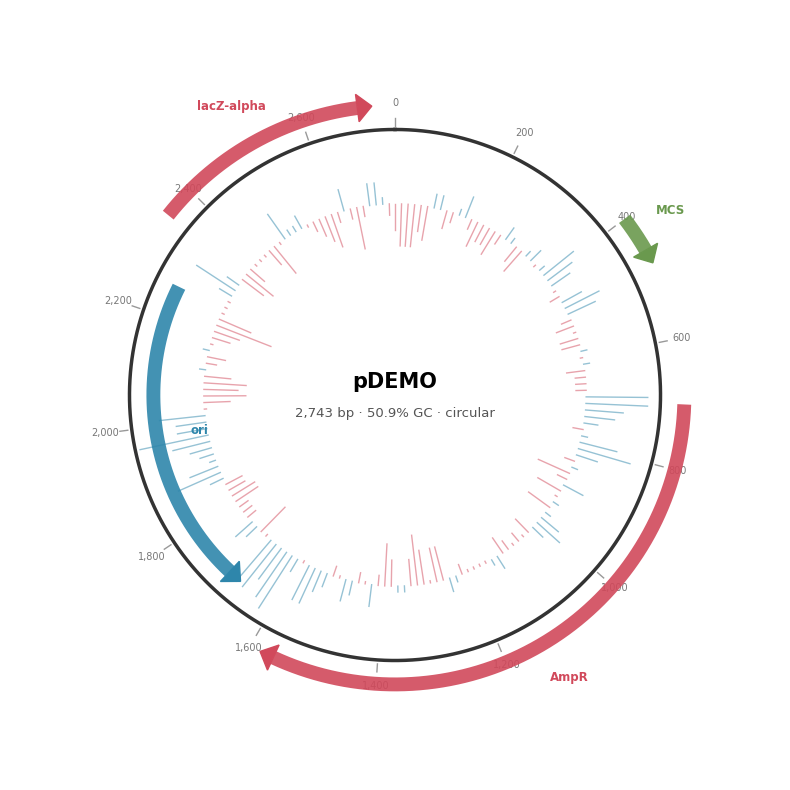


[3] Linear map + GC-skew


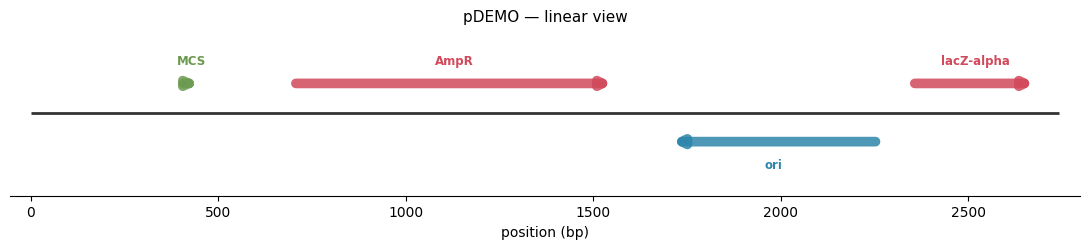

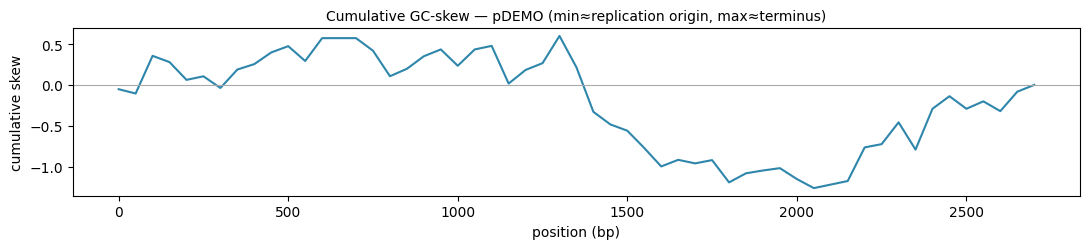


[4] Restriction analysis
── Restriction map of pDEMO (circular) ──
unique (single) cutters: KpnI, PstI, XbaI
cutting enzymes (site count):
  XbaI       1x  at [429]
  PstI       1x  at [445]
  KpnI       1x  at [418]
  SphI       2x  at [451, 2344]
  EcoRI      2x  at [402, 1053]
  BamHI      2x  at [423, 1967]
  SalI       3x  at [183, 435, 594]
  SacI       3x  at [412, 1515, 1884]
  HindIII    4x  at [339, 453, 622, 1245]

[5] Virtual digests on a gel


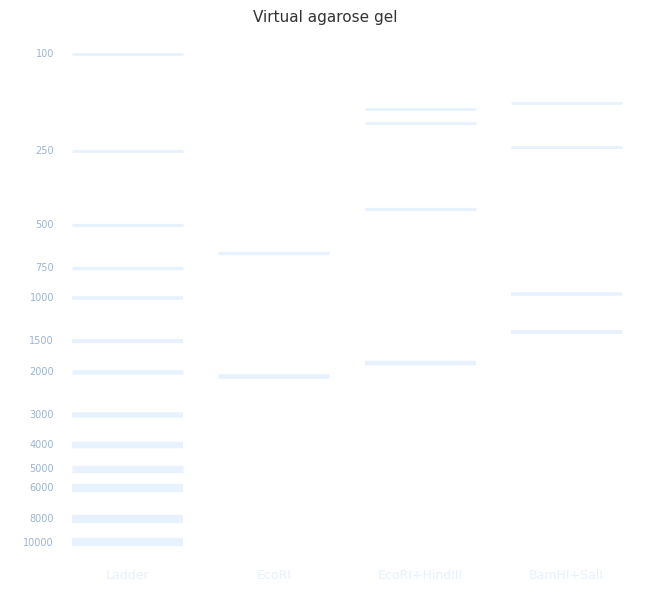


[6] Six-frame ORF scan (top 5 by length)
  strand -1 frame 0  531-783  83 aa
  strand -1 frame 2  1901-2084  60 aa
  strand +1 frame 1  1105-1264  52 aa
  strand +1 frame 1  2581-2740  52 aa
  strand -1 frame 0  1173-1326  50 aa

[7] Translate a CDS feature
  AmpR protein (26 aa): PLWASAGSAGHLRRGSDRVLEETCPP...

[8] Design primers to amplify a region
── Primers to amplify 400–900 (500 bp) ──
  FWD  5'-GAATTCGAGCTCGGTACCCGGG-3'   len 22  Tm 59.1°C  GC 64%
  REV  5'-CTATAGCTTAAAATTAGCGTGGATAAACCG-3'   len 30  Tm 55.1°C  GC 37%
  amplicon: 500 bp

[9] Edit the sequence (insert a 6-bp tag) and re-map
＋ added pDEMO_edit (now 2 in library)

[10] Library
  pDEMO              2,743 bp   50.9% GC
  pDEMO_edit         2,752 bp   50.8% GC

Done. Call any function directly, e.g. circular_map(edited).


In [1]:
if __name__ == "__main__":
    rec = load_record()
    add_to_library(rec)

    print("\n[1] Sequence statistics")
    stats(rec)

    print("\n[2] Circular map (the signature SpliceCraft view)")
    circular_map(rec)

    print("\n[3] Linear map + GC-skew")
    linear_map(rec)
    gc_skew_plot(rec)

    print("\n[4] Restriction analysis")
    restriction_report(rec, enzymes=["EcoRI", "BamHI", "HindIII", "PstI",
                                     "SalI", "XbaI", "KpnI", "SacI", "SphI"])

    print("\n[5] Virtual digests on a gel")
    virtual_gel({
        "EcoRI":         digest_fragments(rec, ["EcoRI"]),
        "EcoRI+HindIII": digest_fragments(rec, ["EcoRI", "HindIII"]),
        "BamHI+SalI":    digest_fragments(rec, ["BamHI", "SalI"]),
    })

    print("\n[6] Six-frame ORF scan (top 5 by length)")
    for strand, frame, s, e, aa in find_orfs(rec, min_aa=40)[:5]:
        print(f"  strand {strand:+d} frame {frame}  {s}-{e}  {aa} aa")

    print("\n[7] Translate a CDS feature")
    prot = translate_feature(rec, "AmpR")
    if prot: print(f"  AmpR protein ({len(prot)} aa): {prot[:60]}...")

    print("\n[8] Design primers to amplify a region")
    design_primers(rec, 400, 900)

    print("\n[9] Edit the sequence (insert a 6-bp tag) and re-map")
    edited = edit_sequence(rec, pos=456, insert="CATCATCAT")
    add_to_library(edited)

    print("\n[10] Library"); show_library()
    print("\nDone. Call any function directly, e.g. circular_map(edited).")